# Feature-Based Regression Model

## Objective

This notebook develops a feature-based regression model to forecast weekly German electricity demand using XGBoost.

In addition to lag and calendar features, weekly Berlin temperature variables are included as explanatory variables. The model is evaluated on the final two years of the dataset using RMSE, MAE and MAPE.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor

## Load Weekly Electricity Demand and Temperature Data

The processed weekly electricity demand dataset and weekly temperature dataset are loaded and merged using their timestamp index.

In [2]:
# Load electricity demand

weekly_load = pd.read_csv(
    "weekly_load.csv",
    index_col=0,
    parse_dates=True
)

# Load weekly temperature

weekly_temperature = pd.read_csv(
    "weekly_temperature.csv",
    index_col=0,
    parse_dates=True
)

## Align Timestamp Index

The temperature dataset is converted to UTC to ensure consistency with the electricity demand dataset before merging.

In [3]:
weekly_temperature.index = weekly_temperature.index.tz_localize("UTC")

## Merge Electricity Demand and Temperature Data

The weekly electricity demand and temperature datasets are merged to create the modelling dataset.

In [4]:
data = weekly_load.join(
    weekly_temperature,
    how="inner"
)

data.head()

,load,temp_mean,heating_degree,cooling_degree
timestamp,,,,
2015-01-04 00:00:00+00:00,47233.739583,2.800000,15.200000,0.0
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0


## Inspect the Dataset

The merged dataset is checked for missing values and the availability of all predictor variables.

In [5]:
print(data.info())

print(data.isna().sum())

data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301 entries, 2015-01-04 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   load            301 non-null    float64
 1   temp_mean       301 non-null    float64
 2   heating_degree  301 non-null    float64
 3   cooling_degree  301 non-null    float64
dtypes: float64(4)
memory usage: 11.8 KB
None
load              0
temp_mean         0
heating_degree    0
cooling_degree    0
dtype: int64


,load,temp_mean,heating_degree,cooling_degree
timestamp,,,,
2015-01-04 00:00:00+00:00,47233.739583,2.800000,15.200000,0.0
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0


## Forecast Evaluation Function

A reusable evaluation function is defined to calculate RMSE, MAE and MAPE for comparing model performance.

In [ ]:
def evaluate_forecast(actual, forecast):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Feature Engineering

Calendar-based and cyclical features are generated from the timestamp to capture seasonal patterns in electricity demand.

In [ ]:
weekly_load["month"] = weekly_load.index.month

weekly_load["quarter"] = weekly_load.index.quarter

weekly_load["week"] = weekly_load.index.isocalendar().week.astype(int)

weekly_load["year"] = weekly_load.index.year

weekly_load["month_sin"] = np.sin(2*np.pi*weekly_load["month"]/12)

weekly_load["month_cos"] = np.cos(2*np.pi*weekly_load["month"]/12)

weekly_load["week_sin"] = np.sin(2*np.pi*weekly_load["week"]/52)

weekly_load["week_cos"] = np.cos(2*np.pi*weekly_load["week"]/52)

## Train-Test Split

The dataset is divided into training and testing subsets using the final 104 observations as the forecasting horizon.

In [ ]:
forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


## Model Training

The XGBoost Regressor is trained using the engineered calendar-based features. XGBoost is an ensemble machine learning algorithm that combines multiple decision trees to model complex non-linear relationships in the data.

In [ ]:
# Select feature columns

feature_columns = [
    "month",
    "quarter",
    "week",
    "year",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos"
]

X_train = train[feature_columns]

X_test = test[feature_columns]

y_train = train["load"]

y_test = test["load"]

In [ ]:
# Train XGBoost model

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature Importance

Feature importance is examined to identify which engineered variables contribute most to forecasting weekly electricity demand.

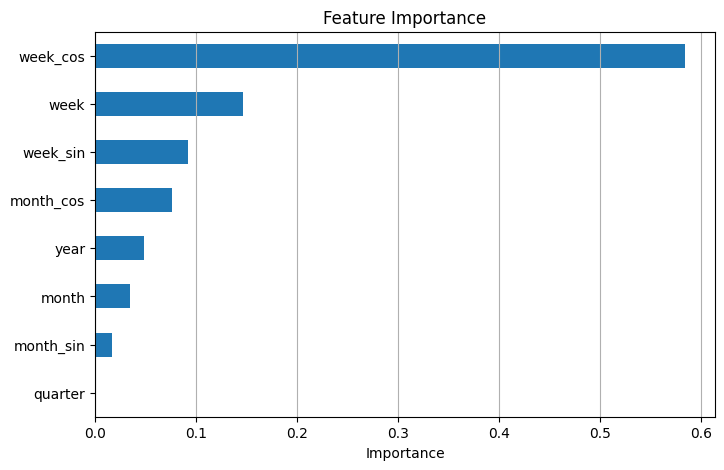

In [ ]:
# Plot feature importance

importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.grid(axis="x")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecasting

The trained XGBoost model is used to generate forecasts for the testing period.

In [ ]:
# Generate forecasts

feature_forecast = xgb_model.predict(X_test)

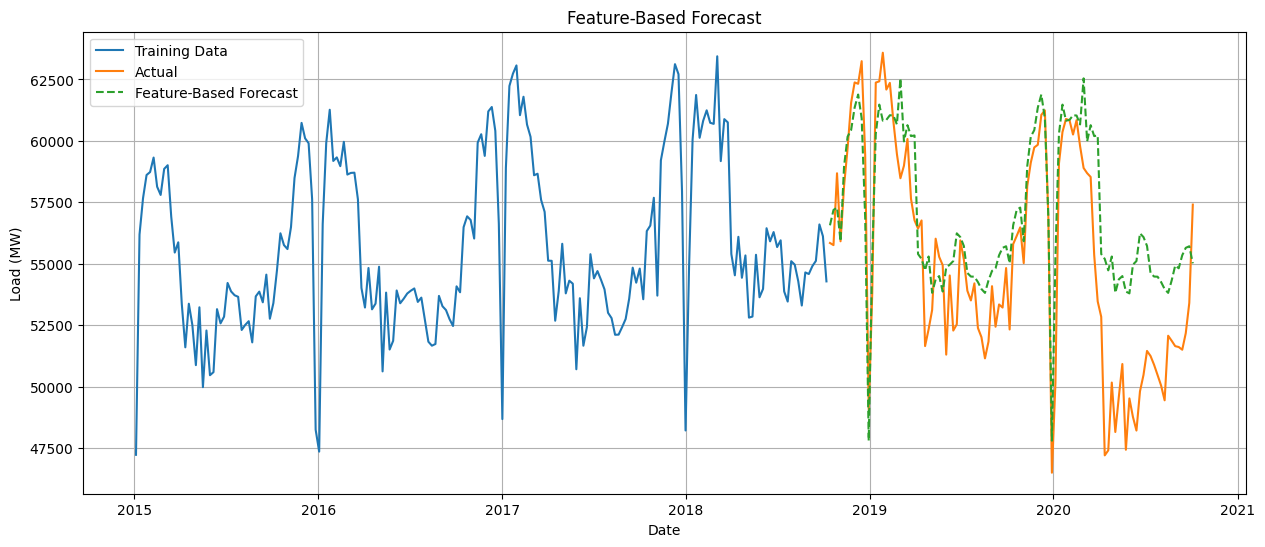

In [ ]:
# Plot forecasts

plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    y_test,
    label="Actual"
)

plt.plot(
    test.index,
    feature_forecast,
    linestyle="--",
    label="Feature-Based Forecast"
)

plt.title("Feature-Based Forecast")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.grid(True)

plt.savefig(
    "feature_model_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation

The forecasting performance of the feature-based model is evaluated using RMSE, MAE and MAPE.

In [ ]:
feature_metrics = evaluate_forecast(
    y_test,
    feature_forecast
)

print(feature_metrics)

{'RMSE': np.float64(2965.1526684039372), 'MAE': 2307.1086780515493, 'MAPE': np.float64(4.392008157155215)}


In [ ]:
feature_metrics_df = pd.DataFrame(
    [feature_metrics]
)

feature_metrics_df.to_csv(
    "feature_model_metrics.csv",
    index=False
)

feature_metrics_df

,RMSE,MAE,MAPE
0,2965.152668,2307.108678,4.392008


In [ ]:
forecast_df = pd.DataFrame({
    "Actual": y_test,
    "Forecast": feature_forecast
})

forecast_df.to_csv(
    "feature_model_forecast.csv"
)

forecast_df.head()

,Actual,Forecast
timestamp,,
2018-10-14 00:00:00+00:00,55848.940476,56567.761719
2018-10-21 00:00:00+00:00,55762.125000,57192.148438
2018-10-28 00:00:00+00:00,58684.714286,57288.710938
2018-11-04 00:00:00+00:00,55917.589286,55920.410156
2018-11-11 00:00:00+00:00,58163.470238,58968.070312
